# Ames House Prices: Baseline to Feature Engineering

This notebook develops an interview-ready regression workflow for predicting `SalePrice`.

The work is deliberately split into two stages:

1. **Baseline:** data checks, a fixed holdout set, basic preprocessing, and plain linear regression with no engineered predictors.
2. **Extensions:** a log target, interpretable housing features, skew transformations, regularized linear models, random-forest feature selection, and gradient boosting.

The baseline is the reference point. Later complexity should earn its place through better out-of-sample performance, more stable residuals, or a clearer explanation of the price-setting process.

## 1. Setup and evaluation principles

The Kaggle competition evaluates predictions using root mean squared logarithmic error (RMSLE). This reduces the dominance of the most expensive homes and treats proportional errors more evenly across the price range.

This notebook also reports:

- **RMSE:** penalizes large errors in dollars.
- **MAE:** typical absolute error in dollars and easier to explain.
- **R-squared:** proportion of target variance explained.
- **RMSLE:** primary model-ranking metric for this dataset.

All learned preprocessing stays inside scikit-learn pipelines. Imputation, scaling, encoding, skew transformations, feature engineering, and feature selection are therefore fitted independently within each cross-validation fold.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    make_scorer,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

## 2. Load and understand the data

The Kaggle files are expected to be in the same folder as this notebook. `train.csv` contains `SalePrice`; `test.csv` is the unlabelled Kaggle scoring set.

`MSSubClass` and `MoSold` are numeric codes rather than continuous measurements, so they are converted to strings before modeling. This is semantic type correction, not feature engineering.

In [11]:
TRAIN_PATH = Path("train.csv")
KAGGLE_TEST_PATH = Path("test.csv")
SAMPLE_SUBMISSION_PATH = Path("sample_submission.csv")

required_files = [TRAIN_PATH, KAGGLE_TEST_PATH, SAMPLE_SUBMISSION_PATH]
missing_files = [path.name for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        f"Missing files: {missing_files}. Start Jupyter in the HousePriceRegression folder."
    )

housing = pd.read_csv(TRAIN_PATH)
kaggle_test = pd.read_csv(KAGGLE_TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

for frame in (housing, kaggle_test):
    frame["MSSubClass"] = frame["MSSubClass"].astype(str)
    frame["MoSold"] = frame["MoSold"].astype(str)

print(f"Training rows and columns: {housing.shape}")
print(f"Kaggle test rows and columns: {kaggle_test.shape}")
housing.head()

Training rows and columns: (1460, 81)
Kaggle test rows and columns: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0000,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,"2,003.0000",RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,"1,976.0000",RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,"2,001.0000",RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0000,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,"1,998.0000",Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0000,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,"2,000.0000",RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [12]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   str    
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [13]:
housing.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,"1,460.0000",NaN,NaN,NaN,730.5000,421.6100,1.0000,365.7500,730.5000,"1,095.2500","1,460.0000"
MSSubClass,1460,15,20,536,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MSZoning,1460,5,RL,1151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotFrontage,"1,201.0000",NaN,NaN,NaN,70.0500,24.2848,21.0000,59.0000,69.0000,80.0000,313.0000
LotArea,"1,460.0000",NaN,NaN,NaN,"10,516.8281","9,981.2649","1,300.0000","7,553.5000","9,478.5000","11,601.5000","215,245.0000"
...,...,...,...,...,...,...,...,...,...,...,...
MoSold,1460,12,6,253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YrSold,"1,460.0000",NaN,NaN,NaN,"2,007.8158",1.3281,"2,006.0000","2,007.0000","2,008.0000","2,009.0000","2,010.0000"
SaleType,1460,9,WD,1267,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SaleCondition,1460,6,Normal,1198,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Data-quality checks

Check identifiers, duplicates, target validity, date consistency, and impossible measurements before studying model performance. Outliers are flagged but not automatically removed; removing valid expensive or unusually large homes would change the population being modeled.

In [14]:
quality_checks = pd.Series({
    "duplicate_rows": housing.duplicated().sum(),
    "duplicate_ids": housing["Id"].duplicated().sum(),
    "missing_ids": housing["Id"].isna().sum(),
    "missing_target": housing["SalePrice"].isna().sum(),
    "nonpositive_sale_price": (housing["SalePrice"] <= 0).sum(),
    "nonpositive_living_area": (housing["GrLivArea"] <= 0).sum(),
    "year_built_after_sale": (housing["YearBuilt"] > housing["YrSold"]).sum(),
    "remodel_year_after_sale": (housing["YearRemodAdd"] > housing["YrSold"]).sum(),
    "garage_year_after_sale": (housing["GarageYrBlt"] > housing["YrSold"]).sum(),
})
quality_checks.to_frame("count")

,count
duplicate_rows,0
duplicate_ids,0
missing_ids,0
missing_target,0
nonpositive_sale_price,0
nonpositive_living_area,0
year_built_after_sale,0
remodel_year_after_sale,1
garage_year_after_sale,0


### Missing values: absence versus unknown

In Ames Housing, many `NA` values are documented as the physical absence of a feature. For example, a missing `PoolQC` usually means there is no pool, not that somebody forgot to inspect it.

The `expected_absence` list below is filled with an explicit `"None"` category. Remaining categorical gaps use the most frequent training category, and numerical gaps use the training median. `MasVnrType` is treated conservatively as ordinary missingness because its interpretation is less clear.

In [15]:
ABSENCE_CATEGORICAL = [
    "Alley",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PoolQC",
    "Fence",
    "MiscFeature",
]

missing_summary = (
    housing.isna()
    .agg(["sum", "mean"])
    .T
    .rename(columns={"sum": "missing_count", "mean": "missing_rate"})
    .query("missing_count > 0")
    .sort_values("missing_rate", ascending=False)
)
missing_summary["interpretation"] = np.where(
    missing_summary.index.isin(ABSENCE_CATEGORICAL),
    "expected structural absence",
    "ordinary missing value",
)
missing_summary

,missing_count,missing_rate,interpretation
PoolQC,"1,453.0000",0.9952,expected structural absence
MiscFeature,"1,406.0000",0.9630,expected structural absence
Alley,"1,369.0000",0.9377,expected structural absence
Fence,"1,179.0000",0.8075,expected structural absence
MasVnrType,872.0000,0.5973,ordinary missing value
FireplaceQu,690.0000,0.4726,expected structural absence
LotFrontage,259.0000,0.1774,ordinary missing value
GarageType,81.0000,0.0555,expected structural absence
GarageYrBlt,81.0000,0.0555,ordinary missing value
GarageFinish,81.0000,0.0555,expected structural absence


### Target distribution and scale

`SalePrice` is strongly right-skewed. A few expensive homes can dominate squared error on the raw scale, while a logarithmic target often makes residual variance more stable and aligns with Kaggle's RMSLE metric.

In [16]:
target_summary = housing["SalePrice"].describe().to_frame("SalePrice")
target_summary.loc["skew"] = housing["SalePrice"].skew()
target_summary

,SalePrice
count,"1,460.0000"
mean,"180,921.1959"
std,"79,442.5029"
min,"34,900.0000"
25%,"129,975.0000"
50%,"163,000.0000"
75%,"214,000.0000"
max,"755,000.0000"
skew,1.8829


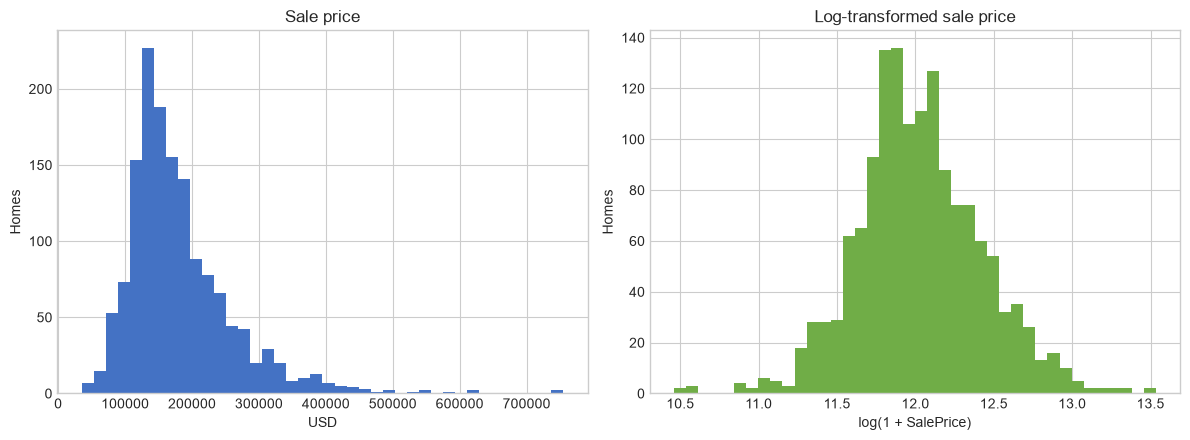

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
housing["SalePrice"].hist(bins=40, ax=axes[0], color="#4472C4")
axes[0].set(title="Sale price", xlabel="USD", ylabel="Homes")
np.log1p(housing["SalePrice"]).hist(bins=40, ax=axes[1], color="#70AD47")
axes[1].set(title="Log-transformed sale price", xlabel="log(1 + SalePrice)", ylabel="Homes")
plt.tight_layout()
plt.show()

### Numerical and categorical relationships

Correlation is a screen for linear association, not a feature-selection rule. For categorical variables, group summaries should be read alongside sample sizes because small categories can produce unstable price averages.

In [18]:
numeric_correlations = (
    housing.select_dtypes(include=np.number)
    .corr()["SalePrice"]
    .drop("SalePrice")
    .sort_values(key=abs, ascending=False)
)
numeric_correlations.head(20).to_frame("correlation_with_sale_price")

,correlation_with_sale_price
OverallQual,0.7910
GrLivArea,0.7086
GarageCars,0.6404
GarageArea,0.6234
TotalBsmtSF,0.6136
1stFlrSF,0.6059
FullBath,0.5607
TotRmsAbvGrd,0.5337
YearBuilt,0.5229
YearRemodAdd,0.5071


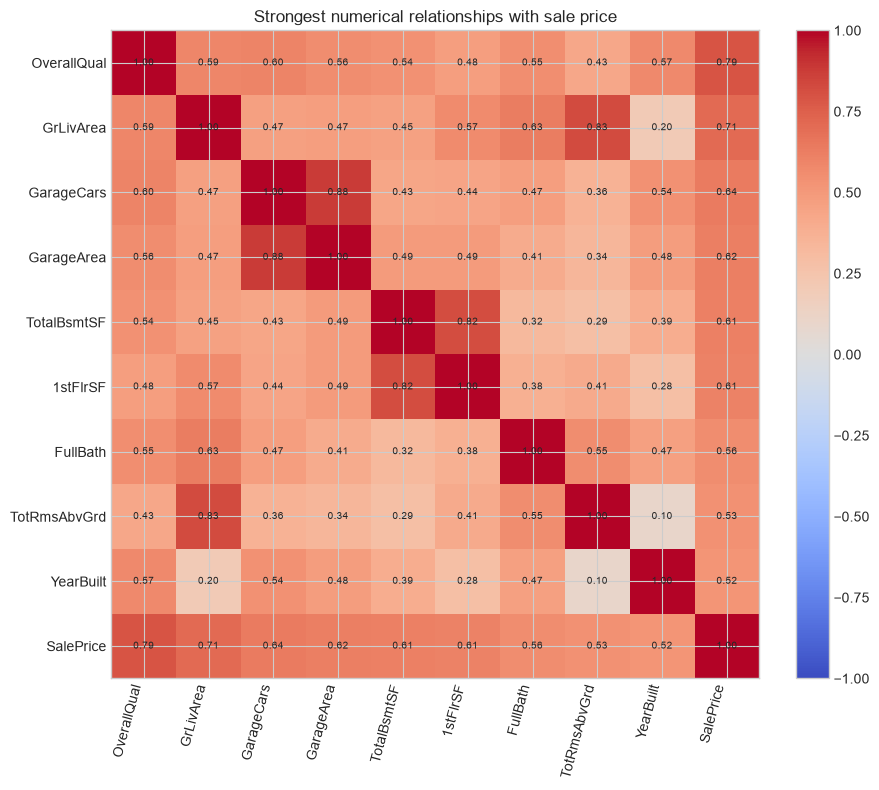

In [19]:
top_numeric = numeric_correlations.head(9).index.tolist() + ["SalePrice"]
corr_subset = housing[top_numeric].corr()

plt.figure(figsize=(10, 8))
image = plt.imshow(corr_subset, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(image, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr_subset)), corr_subset.columns, rotation=75, ha="right")
plt.yticks(range(len(corr_subset)), corr_subset.index)
for row in range(len(corr_subset)):
    for column in range(len(corr_subset)):
        plt.text(column, row, f"{corr_subset.iloc[row, column]:.2f}", ha="center", va="center", fontsize=7)
plt.title("Strongest numerical relationships with sale price")
plt.tight_layout()
plt.show()

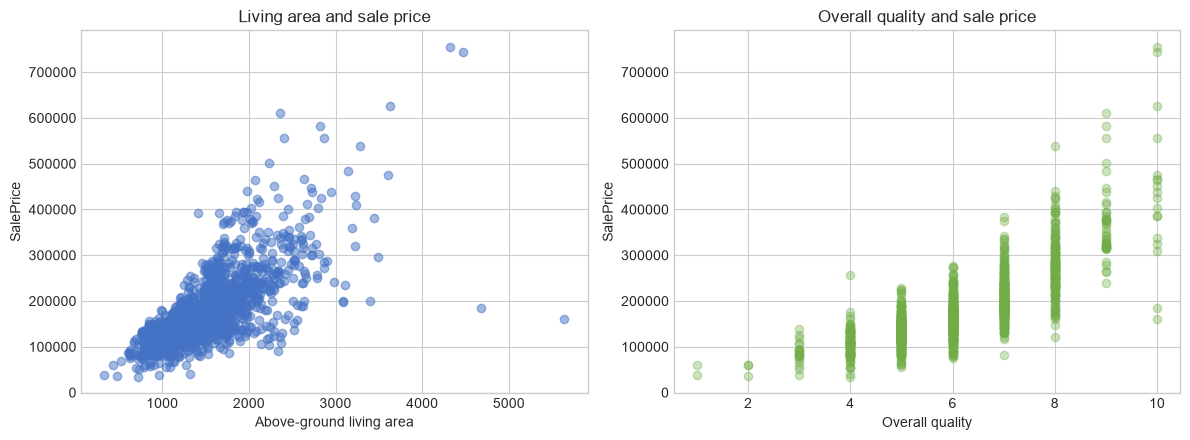

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(housing["GrLivArea"], housing["SalePrice"], alpha=0.5, color="#4472C4")
axes[0].set(title="Living area and sale price", xlabel="Above-ground living area", ylabel="SalePrice")
axes[1].scatter(housing["OverallQual"], housing["SalePrice"], alpha=0.35, color="#70AD47")
axes[1].set(title="Overall quality and sale price", xlabel="Overall quality", ylabel="SalePrice")
plt.tight_layout()
plt.show()

In [21]:
for column in ["Neighborhood", "HouseStyle", "SaleCondition", "KitchenQual"]:
    table = (
        housing.groupby(column, dropna=False)["SalePrice"]
        .agg(count="size", median_price="median", mean_price="mean")
        .sort_values("median_price", ascending=False)
    )
    print(f"\n{column}")
    display(table)


Neighborhood


,count,median_price,mean_price
Neighborhood,,,
NridgHt,77,"315,000.0000","316,270.6234"
NoRidge,41,"301,500.0000","335,295.3171"
StoneBr,25,"278,000.0000","310,499.0000"
Timber,38,"228,475.0000","242,247.4474"
Somerst,86,"225,500.0000","225,379.8372"
Veenker,11,"218,000.0000","238,772.7273"
Crawfor,51,"200,624.0000","210,624.7255"
ClearCr,28,"200,250.0000","212,565.4286"
CollgCr,150,"197,200.0000","197,965.7733"



HouseStyle


,count,median_price,mean_price
HouseStyle,,,
2.5Fin,8,"194,000.0000","220,000.0000"
2Story,445,"190,000.0000","210,051.7640"
SLvl,65,"164,500.0000","166,703.3846"
1Story,726,"154,750.0000","175,985.4780"
SFoyer,37,"135,960.0000","135,074.4865"
2.5Unf,11,"133,900.0000","157,354.5455"
1.5Fin,154,"132,000.0000","143,116.7403"
1.5Unf,14,"111,250.0000","110,150.0000"



SaleCondition


,count,median_price,mean_price
SaleCondition,,,
Partial,125,"244,600.0000","272,291.7520"
Normal,1198,"160,000.0000","175,202.2195"
Alloca,12,"148,145.0000","167,377.4167"
Family,20,"140,500.0000","149,600.0000"
Abnorml,101,"130,000.0000","146,526.6238"
AdjLand,4,"104,000.0000","104,125.0000"



KitchenQual


,count,median_price,mean_price
KitchenQual,,,
Ex,100,"316,750.0000","328,554.6700"
Gd,586,"201,400.0000","212,116.0239"
TA,735,"137,000.0000","139,962.5116"
Fa,39,"115,000.0000","105,565.2051"


## 3. Define the holdout set

`Id` is excluded because it is an identifier rather than a property characteristic. The labelled data is split before any learned preprocessing.

Regression has no classes to stratify, so the target is divided into ten quantile bands for the holdout split. This keeps inexpensive and expensive homes represented in both partitions. Cross-validation later uses shuffled `KFold` splits.

In [22]:
TARGET = "SalePrice"
ID_COLUMN = "Id"

X = housing.drop(columns=[TARGET, ID_COLUMN])
y = housing[TARGET].astype(float)

price_bands = pd.qcut(y, q=10, duplicates="drop") # remove this line if do not want to stratify
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=price_bands,  # remove this if do not want to stratify
)

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_test)],
    "mean_price": [y_train.mean(), y_test.mean()],
    "median_price": [y_train.median(), y_test.median()],
    "minimum_price": [y_train.min(), y_test.min()],
    "maximum_price": [y_train.max(), y_test.max()],
}, index=["train", "test"])
split_summary

,rows,mean_price,median_price,minimum_price,maximum_price
train,1168,"180,976.8861","163,000.0000","34,900.0000","755,000.0000"
test,292,"180,698.4349","163,495.0000","35,311.0000","625,000.0000"


## 4. Baseline preprocessing

The baseline deliberately contains no engineered predictors and no feature selection.

- Numerical features: median imputation, then standardization.
- Nominal features: an explicit missing category, then one-hot encoding.
- Ordinal features: encode the declared order, then median-impute the encoded rank.
- Structural absence in an ordinal feature can be declared as a genuine ordered level.
- Previously unseen nominal categories are ignored; unseen ordinal categories receive the training median rank.
- Model: ordinary least squares linear regression.

Scaling is not required for unregularized linear regression, but including it makes coefficients easier to compare and lets the same preprocessing support Ridge and Lasso later.

In [24]:
# Edit these mappings for a new dataset. Values must run from lowest to highest.
ORDINAL_CATEGORIES = {
    "ExterQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "ExterCond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtQual": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtCond": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtExposure": ["None", "No", "Mn", "Av", "Gd"],
    "BsmtFinType1": ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFinType2": ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "HeatingQC": ["Po", "Fa", "TA", "Gd", "Ex"],
    "KitchenQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "FireplaceQu": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageFinish": ["None", "Unf", "RFn", "Fin"],
    "GarageQual": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageCond": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "PoolQC": ["None", "Fa", "TA", "Gd", "Ex"],
    "Functional": ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    "PavedDrive": ["N", "P", "Y"],
}

# Here NaN means the feature is absent, rather than merely unknown.
ORDINAL_STRUCTURAL_ABSENCE = {
    column: "None"
    for column in [
        "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1",
        "BsmtFinType2", "FireplaceQu", "GarageFinish",
        "GarageQual", "GarageCond", "PoolQC",
    ]
}


def select_numeric(frame):
    return [
        column for column in frame.select_dtypes(include=np.number).columns
        if column not in ORDINAL_CATEGORIES
    ]


def select_nominal(frame):
    return [
        column for column in frame.select_dtypes(exclude=np.number).columns
        if column not in ORDINAL_CATEGORIES
    ]


def make_ordinal_pipeline(column):
    steps = []
    if column in ORDINAL_STRUCTURAL_ABSENCE:
        steps.append((
            "structural_absence",
            SimpleImputer(
                strategy="constant",
                fill_value=ORDINAL_STRUCTURAL_ABSENCE[column],
            ),
        ))

    steps.extend([
        (
            "ordinal",
            OrdinalEncoder(
                categories=[ORDINAL_CATEGORIES[column]],
                handle_unknown="use_encoded_value",
                unknown_value=np.nan,
                encoded_missing_value=np.nan,
            ),
        ),
        ("imputer", SimpleImputer(strategy="median")),
    ])
    return Pipeline(steps)


def make_preprocessor(*, dense=False, scale_numeric=True):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    transformers = [
        ("numeric", Pipeline(numeric_steps), select_numeric),
        (
            "nominal",
            Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="__MISSING__")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=not dense)),
            ]),
            select_nominal,
        ),
    ]

    transformers.extend(
        (f"ordinal_{column}", make_ordinal_pipeline(column), [column])
        for column in ORDINAL_CATEGORIES
    )
    return ColumnTransformer(transformers)


baseline_preprocessor = make_preprocessor()

dummy_model = Pipeline([
    ("preprocess", clone(baseline_preprocessor)),
    ("model", DummyRegressor(strategy="median")),
])

baseline_linear = Pipeline([
    ("preprocess", clone(baseline_preprocessor)),
    ("model", LinearRegression()),
])

### Reusable cross-validation comparison

The test set remains untouched. Models are ranked using five-fold cross-validation on the training partition only. Predictions are clipped at zero when computing RMSLE because negative prices are invalid and logarithms require nonnegative inputs.

In [25]:
def rmsle_clipped(y_true, y_pred):
    y_pred = np.clip(np.asarray(y_pred), 0, None)
    y_true = np.asarray(y_true)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))


cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
    "rmsle": make_scorer(rmsle_clipped, greater_is_better=False),
}


def evaluate_model_cv(name, estimator, X_data=X_train, y_data=y_train):
    scores = cross_validate(
        estimator,
        X_data,
        y_data,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )
    return {
        "model": name,
        "rmse_mean": -scores["test_rmse"].mean(),
        "rmse_std": scores["test_rmse"].std(),
        "mae_mean": -scores["test_mae"].mean(),
        "mae_std": scores["test_mae"].std(),
        "r2_mean": scores["test_r2"].mean(),
        "r2_std": scores["test_r2"].std(),
        "rmsle_mean": -scores["test_rmsle"].mean(),
        "rmsle_std": scores["test_rmsle"].std(),
        "fit_time_seconds": scores["fit_time"].mean(),
    }


baseline_results = [
    evaluate_model_cv("Median dummy", dummy_model),
    evaluate_model_cv("Baseline linear", baseline_linear),
]
pd.DataFrame(baseline_results).set_index("model").T

model,Median dummy,Baseline linear
rmse_mean,"81,244.8529","38,768.5935"
rmse_std,"6,411.8016","10,815.9427"
mae_mean,"55,650.8390","21,236.6067"
mae_std,"2,979.7436","1,693.9286"
r2_mean,-0.0613,0.7267
r2_std,0.0370,0.1859
rmsle_mean,0.3983,0.5004
rmsle_std,0.0173,0.3894
fit_time_seconds,0.0574,0.1108


### Diagnose the raw-target baseline

Residual plots test whether errors are centered, whether variance changes with predicted price, and whether a few observations dominate RMSE. A funnel shape or strong right tail supports transforming the target or predictors.

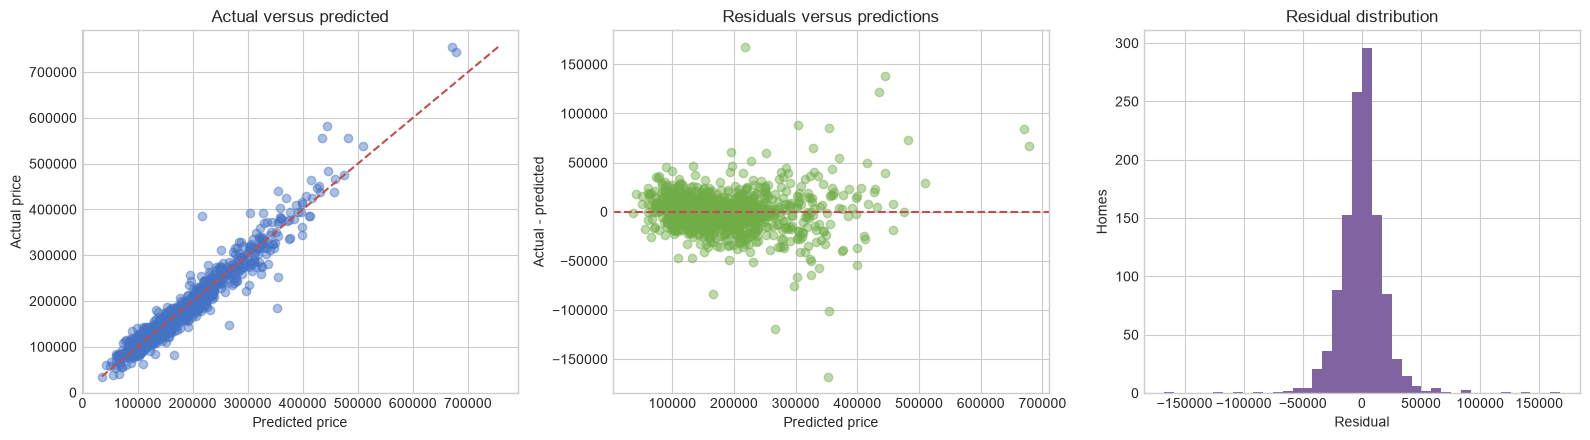

In [16]:
baseline_linear.fit(X_train, y_train)
baseline_train_prediction = baseline_linear.predict(X_train)
baseline_train_residual = y_train - baseline_train_prediction

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].scatter(baseline_train_prediction, y_train, alpha=0.45, color="#4472C4")
line_limits = [min(y_train.min(), baseline_train_prediction.min()), max(y_train.max(), baseline_train_prediction.max())]
axes[0].plot(line_limits, line_limits, color="#C0504D", linestyle="--")
axes[0].set(title="Actual versus predicted", xlabel="Predicted price", ylabel="Actual price")
axes[1].scatter(baseline_train_prediction, baseline_train_residual, alpha=0.45, color="#70AD47")
axes[1].axhline(0, color="#C0504D", linestyle="--")
axes[1].set(title="Residuals versus predictions", xlabel="Predicted price", ylabel="Actual - predicted")
axes[2].hist(baseline_train_residual, bins=40, color="#8064A2")
axes[2].set(title="Residual distribution", xlabel="Residual", ylabel="Homes")
plt.tight_layout()
plt.show()

## 5. Log-transform the target

The first extension changes no input features. It fits linear regression to `log(1 + SalePrice)` and converts predictions back to dollars using `expm1`.

This is an important comparison: it isolates the effect of target transformation before any feature engineering or model change.

In [17]:
def with_log_target(regressor):
    return TransformedTargetRegressor(
        regressor=regressor,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=True,
    )


log_target_linear = with_log_target(Pipeline([
    ("preprocess", make_preprocessor()),
    ("model", LinearRegression()),
]))

log_target_result = evaluate_model_cv("Linear with log target", log_target_linear)
pd.DataFrame([*baseline_results, log_target_result]).set_index("model")

,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std,rmsle_mean,rmsle_std,fit_time_seconds
model,,,,,,,,,
Median dummy,"81,244.8529","6,411.8016","55,650.8390","2,979.7436",-0.0613,0.0370,0.3983,0.0173,0.0782
Baseline linear,"50,599.0439","35,876.4306","21,369.1750","4,510.6137",0.3213,1.0136,0.5441,0.3229,0.2751
Linear with log target,"44,206.2683","28,229.6151","18,338.7224","4,007.6562",0.5219,0.6102,0.1628,0.0484,0.2747


## 6. Feature engineering and skew transformation

The engineered predictors are few, transparent, and tied to housing economics:

- `TotalSF`: basement plus first- and second-floor area.
- `TotalBathrooms`: full bathrooms plus half-weighted half bathrooms.
- `HouseAgeAtSale`: sale year minus construction year.
- `YearsSinceRemodel`: sale year minus latest remodel year.
- `TotalPorchSF`: combined porch and deck area.
- `TotalOutdoorAmenitySF`: porch area plus pool area.
- `QualityLivingArea`: interaction between overall quality and living area.
- Presence indicators for basement, garage, fireplace, pool, second floor, and remodeling.

The skew transformer identifies nonnegative numerical columns with absolute training-set skew above 0.75 and applies `log1p`. Selection occurs in `fit()`, so each validation fold decides using only its training rows.

In [18]:
class AmesFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        X["TotalSF"] = X[["TotalBsmtSF", "1stFlrSF", "2ndFlrSF"]].sum(axis=1, min_count=1)
        X["TotalBathrooms"] = (
            X["FullBath"]
            + 0.5 * X["HalfBath"]
            + X["BsmtFullBath"].fillna(0)
            + 0.5 * X["BsmtHalfBath"].fillna(0)
        )
        X["HouseAgeAtSale"] = (X["YrSold"] - X["YearBuilt"]).clip(lower=0)
        X["YearsSinceRemodel"] = (X["YrSold"] - X["YearRemodAdd"]).clip(lower=0)
        X["TotalPorchSF"] = X[
            ["WoodDeckSF", "OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch"]
        ].sum(axis=1, min_count=1)
        X["TotalOutdoorAmenitySF"] = X["TotalPorchSF"] + X["PoolArea"]
        X["QualityLivingArea"] = X["OverallQual"] * X["GrLivArea"]

        X["HasBasement"] = (X["TotalBsmtSF"].fillna(0) > 0).astype(int)
        X["HasGarage"] = (X["GarageArea"].fillna(0) > 0).astype(int)
        X["HasFireplace"] = (X["Fireplaces"].fillna(0) > 0).astype(int)
        X["HasPool"] = (X["PoolArea"].fillna(0) > 0).astype(int)
        X["HasSecondFloor"] = (X["2ndFlrSF"].fillna(0) > 0).astype(int)
        X["WasRemodeled"] = (X["YearRemodAdd"] != X["YearBuilt"]).astype(int)
        return X


class SkewedLogTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, skew_threshold=0.75):
        self.skew_threshold = skew_threshold

    def fit(self, X, y=None):
        X = X.copy()
        numeric = X.select_dtypes(include=np.number)
        nonnegative = [column for column in numeric if numeric[column].min(skipna=True) >= 0]
        skew = numeric[nonnegative].skew().abs()
        self.columns_ = skew[skew > self.skew_threshold].index.tolist()
        return self

    def transform(self, X):
        X = X.copy()
        for column in self.columns_:
            X[column] = np.log1p(X[column])
        return X


engineered_linear = with_log_target(Pipeline([
    ("features", AmesFeatureEngineer()),
    ("skew", SkewedLogTransformer()),
    ("preprocess", make_preprocessor()),
    ("model", LinearRegression()),
]))

engineered_result = evaluate_model_cv("Engineered linear", engineered_linear)
pd.DataFrame([*baseline_results, log_target_result, engineered_result]).set_index("model")

,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std,rmsle_mean,rmsle_std,fit_time_seconds
model,,,,,,,,,
Median dummy,"81,244.8529","6,411.8016","55,650.8390","2,979.7436",-0.0613,0.0370,0.3983,0.0173,0.0782
Baseline linear,"50,599.0439","35,876.4306","21,369.1750","4,510.6137",0.3213,1.0136,0.5441,0.3229,0.2751
Linear with log target,"44,206.2683","28,229.6151","18,338.7224","4,007.6562",0.5219,0.6102,0.1628,0.0484,0.2747
Engineered linear,"31,644.2494","11,953.1821","16,315.1930","1,797.3253",0.8074,0.1631,0.1523,0.0327,0.3822


## 7. Ridge and Lasso regression

One-hot encoding creates many correlated predictors. Regularization is therefore a natural extension:

- **Ridge** shrinks correlated coefficients together and usually keeps every transformed feature.
- **Lasso** can shrink coefficients exactly to zero, providing embedded feature selection.

Both models predict the log target. Their regularization strength is selected using training-set cross-validation and RMSLE.

In [19]:
def make_regularized_model(estimator):
    return with_log_target(Pipeline([
        ("features", AmesFeatureEngineer()),
        ("skew", SkewedLogTransformer()),
        ("preprocess", make_preprocessor()),
        ("model", estimator),
    ]))


ridge_model = make_regularized_model(Ridge(max_iter=20_000))
ridge_search = GridSearchCV(
    ridge_model,
    param_grid={"regressor__model__alpha": [0.1, 1.0, 10.0, 30.0, 100.0]},
    scoring=make_scorer(rmsle_clipped, greater_is_better=False),
    cv=cv,
    n_jobs=1,
    refit=True,
    return_train_score=True,
)
ridge_search.fit(X_train, y_train)

print("Best Ridge alpha:", ridge_search.best_params_["regressor__model__alpha"])
print("Best Ridge CV RMSLE:", round(-ridge_search.best_score_, 4))
pd.DataFrame(ridge_search.cv_results_)[
    ["param_regressor__model__alpha", "mean_train_score", "mean_test_score", "std_test_score"]
].sort_values("mean_test_score", ascending=False)

Best Ridge alpha: 10.0
Best Ridge CV RMSLE: 0.1325


,param_regressor__model__alpha,mean_train_score,mean_test_score,std_test_score
2,10.0000,-0.1018,-0.1325,0.0175
3,30.0000,-0.1097,-0.1331,0.0200
1,1.0000,-0.0894,-0.1353,0.0193
4,100.0000,-0.1196,-0.1358,0.0223
0,0.1000,-0.0840,-0.1447,0.0329


In [20]:
lasso_model = make_regularized_model(Lasso(max_iter=50_000, selection="cyclic"))
lasso_search = GridSearchCV(
    lasso_model,
    param_grid={"regressor__model__alpha": [0.0001, 0.0003, 0.001, 0.003, 0.01]},
    scoring=make_scorer(rmsle_clipped, greater_is_better=False),
    cv=cv,
    n_jobs=1,
    refit=True,
    return_train_score=True,
)
lasso_search.fit(X_train, y_train)

print("Best Lasso alpha:", lasso_search.best_params_["regressor__model__alpha"])
print("Best Lasso CV RMSLE:", round(-lasso_search.best_score_, 4))
pd.DataFrame(lasso_search.cv_results_)[
    ["param_regressor__model__alpha", "mean_train_score", "mean_test_score", "std_test_score"]
].sort_values("mean_test_score", ascending=False)

Best Lasso alpha: 0.0003
Best Lasso CV RMSLE: 0.13


,param_regressor__model__alpha,mean_train_score,mean_test_score,std_test_score
1,0.0003,-0.0944,-0.1300,0.0234
2,0.0010,-0.1100,-0.1301,0.0193
0,0.0001,-0.0877,-0.1360,0.0295
3,0.0030,-0.1281,-0.1366,0.0213
4,0.0100,-0.1408,-0.1439,0.0205


In [21]:
best_lasso = lasso_search.best_estimator_
fitted_lasso_pipeline = best_lasso.regressor_
lasso_feature_names = fitted_lasso_pipeline.named_steps["preprocess"].get_feature_names_out()
lasso_coefficients = pd.Series(
    fitted_lasso_pipeline.named_steps["model"].coef_,
    index=lasso_feature_names,
    name="coefficient_on_log_price",
)
selected_lasso_features = (
    lasso_coefficients[lasso_coefficients.ne(0)]
    .sort_values(key=abs, ascending=False)
    .to_frame()
)

print(f"Selected {len(selected_lasso_features)} of {len(lasso_coefficients)} transformed features")
selected_lasso_features.head(30)

Selected 145 of 336 transformed features


,coefficient_on_log_price
other_category__RoofMatl_ClyTile,-1.1085
other_category__Condition2_PosN,-0.3604
other_category__MSZoning_C (all),-0.3205
other_category__RoofMatl_WdShngl,0.1411
other_category__Neighborhood_Crawfor,0.1315
other_category__Neighborhood_StoneBr,0.1224
other_category__Heating_Grav,-0.1022
other_category__Neighborhood_NoRidge,0.0926
numeric__GrLivArea,0.0901
other_category__Neighborhood_Edwards,-0.0827


## 8. Random forest with impurity-based feature selection

Random forests capture nonlinearities and interactions without specifying them manually. One forest is used inside `SelectFromModel` to retain features with at least median impurity importance; a second forest is fitted on those selected transformed features.

Selection stays inside the pipeline and is repeated within each validation fold. Impurity importance can favor continuous or high-cardinality features, so it is treated as a screening method rather than a causal explanation.

In [22]:
rf_selector = RandomForestRegressor(
    n_estimators=75,
    min_samples_leaf=2,
    max_features=0.6,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_estimator = RandomForestRegressor(
    n_estimators=150,
    min_samples_leaf=2,
    max_features=0.6,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_selected = with_log_target(Pipeline([
    ("features", AmesFeatureEngineer()),
    ("preprocess", make_preprocessor(scale_numeric=False)),
    ("select", SelectFromModel(rf_selector, threshold="median")),
    ("model", rf_estimator),
]))

rf_result = evaluate_model_cv("RF with impurity selection", rf_selected)
rf_result

{'model': 'RF with impurity selection',
 'rmse_mean': np.float64(31115.27977333524),
 'rmse_std': np.float64(3482.7664274407134),
 'mae_mean': np.float64(17410.87744815243),
 'mae_std': np.float64(892.3907335409997),
 'r2_mean': np.float64(0.8449057260371362),
 'r2_std': np.float64(0.013656955853660403),
 'rmsle_mean': np.float64(0.14111765056002465),
 'rmsle_std': np.float64(0.011268365228172655),
 'fit_time_seconds': np.float64(3.977730369567871)}

In [23]:
rf_selected.fit(X_train, y_train)
fitted_rf_pipeline = rf_selected.regressor_
rf_all_feature_names = fitted_rf_pipeline.named_steps["preprocess"].get_feature_names_out()
rf_support = fitted_rf_pipeline.named_steps["select"].get_support()
rf_selected_feature_names = rf_all_feature_names[rf_support]
rf_importance = pd.Series(
    fitted_rf_pipeline.named_steps["model"].feature_importances_,
    index=rf_selected_feature_names,
    name="impurity_importance",
).sort_values(ascending=False)

print(f"Selected {rf_support.sum()} of {len(rf_support)} transformed features")
rf_importance.head(30).to_frame()

Selected 168 of 336 transformed features


,impurity_importance
numeric__QualityLivingArea,0.3713
numeric__OverallQual,0.1778
numeric__TotalSF,0.1634
numeric__HouseAgeAtSale,0.0264
numeric__TotalBsmtSF,0.0169
numeric__YearBuilt,0.0160
numeric__GarageCars,0.0144
numeric__BsmtFinSF1,0.0144
numeric__GrLivArea,0.0126
numeric__TotalBathrooms,0.0113


## 9. Gradient boosting

Boosting builds trees sequentially so later trees correct earlier residuals. Gradient boosting is effective on small tabular datasets and captures nonlinearities and interactions.

The one-hot representation is dense for this estimator. This model also predicts log price, then converts predictions back to dollars.

In [24]:
boosting_model = with_log_target(Pipeline([
    ("features", AmesFeatureEngineer()),
    ("preprocess", make_preprocessor(dense=True, scale_numeric=False)),
    (
        "model",
        GradientBoostingRegressor(
            learning_rate=0.05,
            n_estimators=300,
            max_depth=2,
            min_samples_leaf=10,
            loss="huber",
            random_state=RANDOM_STATE,
        ),
    ),
]))

boosting_result = evaluate_model_cv("Gradient boosting", boosting_model)
boosting_result

{'model': 'Gradient boosting',
 'rmse_mean': np.float64(29158.901665304547),
 'rmse_std': np.float64(3783.964032147764),
 'mae_mean': np.float64(15743.089776642164),
 'mae_std': np.float64(940.7710275549837),
 'r2_mean': np.float64(0.8609422821751854),
 'r2_std': np.float64(0.03602973435034055),
 'rmsle_mean': np.float64(0.130225091588949),
 'rmsle_std': np.float64(0.01651101073756928),
 'fit_time_seconds': np.float64(3.895799684524536)}

## 10. Compare all candidate models

Models are ranked by mean cross-validated RMSLE. The standard deviation matters: a small improvement may not be meaningful if it is smaller than fold-to-fold variability.

The tuned Ridge and Lasso estimators are evaluated again with the same helper so all table rows contain the same metrics.

In [25]:
ridge_result = evaluate_model_cv("Ridge", ridge_search.best_estimator_)
lasso_result = evaluate_model_cv("Lasso", lasso_search.best_estimator_)

all_results = pd.DataFrame([
    *baseline_results,
    log_target_result,
    engineered_result,
    ridge_result,
    lasso_result,
    rf_result,
    boosting_result,
])

model_comparison = (
    all_results[
        [
            "model",
            "rmsle_mean",
            "rmsle_std",
            "rmse_mean",
            "rmse_std",
            "mae_mean",
            "r2_mean",
            "fit_time_seconds",
        ]
    ]
    .sort_values("rmsle_mean")
    .reset_index(drop=True)
)
model_comparison

,model,rmsle_mean,rmsle_std,rmse_mean,rmse_std,mae_mean,r2_mean,fit_time_seconds
0,Lasso,0.1300,0.0234,"31,269.5619","12,009.0596","15,019.0137",0.8122,0.7642
1,Gradient boosting,0.1302,0.0165,"29,158.9017","3,783.9640","15,743.0898",0.8609,3.8958
2,Ridge,0.1325,0.0175,"32,081.4966","9,142.5549","15,541.4946",0.8168,0.1301
3,RF with impurity selection,0.1411,0.0113,"31,115.2798","3,482.7664","17,410.8774",0.8449,3.9777
4,Engineered linear,0.1523,0.0327,"31,644.2494","11,953.1821","16,315.1930",0.8074,0.3822
5,Linear with log target,0.1628,0.0484,"44,206.2683","28,229.6151","18,338.7224",0.5219,0.2747
6,Median dummy,0.3983,0.0173,"81,244.8529","6,411.8016","55,650.8390",-0.0613,0.0782
7,Baseline linear,0.5441,0.3229,"50,599.0439","35,876.4306","21,369.1750",0.3213,0.2751


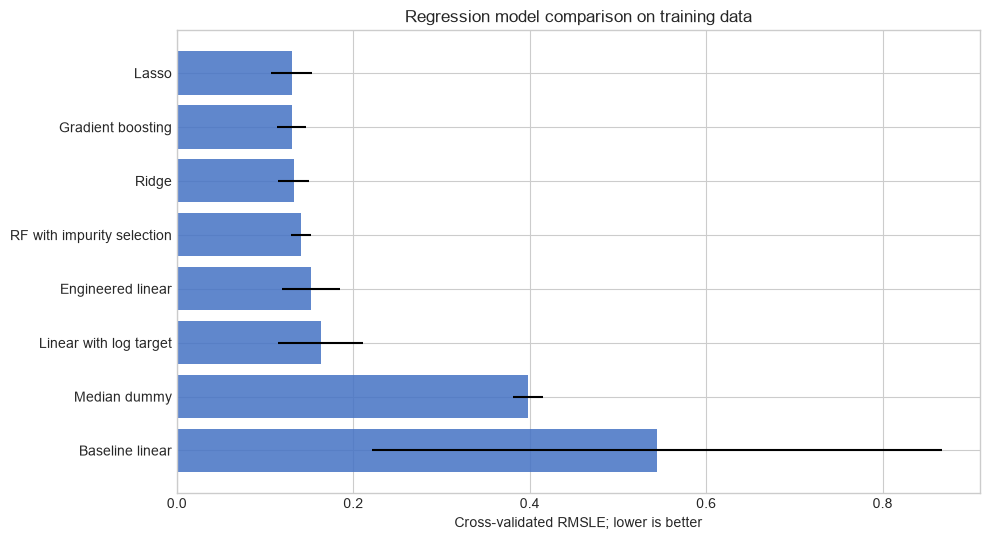

In [26]:
plot_data = model_comparison.sort_values("rmsle_mean", ascending=False)
plt.figure(figsize=(10, 5.5))
plt.barh(
    plot_data["model"],
    plot_data["rmsle_mean"],
    xerr=plot_data["rmsle_std"],
    color="#4472C4",
    alpha=0.85,
)
plt.xlabel("Cross-validated RMSLE; lower is better")
plt.ylabel("")
plt.title("Regression model comparison on training data")
plt.tight_layout()
plt.show()

## 11. Select one model and evaluate the untouched holdout set

The model with the lowest cross-validated RMSLE is selected automatically. This is the first point at which holdout labels are used for performance evaluation.

The holdout is used once for an honest final estimate. It should not be used to choose more features, tune hyperparameters, or select an outlier policy.

In [27]:
candidate_models = {
    "Median dummy": dummy_model,
    "Baseline linear": baseline_linear,
    "Linear with log target": log_target_linear,
    "Engineered linear": engineered_linear,
    "Ridge": ridge_search.best_estimator_,
    "Lasso": lasso_search.best_estimator_,
    "RF with impurity selection": rf_selected,
    "Gradient boosting": boosting_model,
}

selected_model_name = model_comparison.loc[0, "model"]
final_model = clone(candidate_models[selected_model_name])
final_model.fit(X_train, y_train)

test_prediction = np.clip(final_model.predict(X_test), 0, None)
test_metrics = pd.Series({
    "rmse_usd": root_mean_squared_error(y_test, test_prediction),
    "mae_usd": mean_absolute_error(y_test, test_prediction),
    "r2": r2_score(y_test, test_prediction),
    "rmsle": rmsle_clipped(y_test, test_prediction),
}, name="holdout_score")

print("Selected model:", selected_model_name)
test_metrics.to_frame()

Selected model: Lasso


,holdout_score
rmse_usd,"22,608.5210"
mae_usd,"14,009.1996"
r2,0.9203
rmsle,0.1053


### Holdout residual diagnostics

Residual plots can reveal systematic underpricing of expensive homes, changing error variance, or a few influential observations. Errors are also summarized by actual-price quartile to test whether performance is concentrated in one market segment.

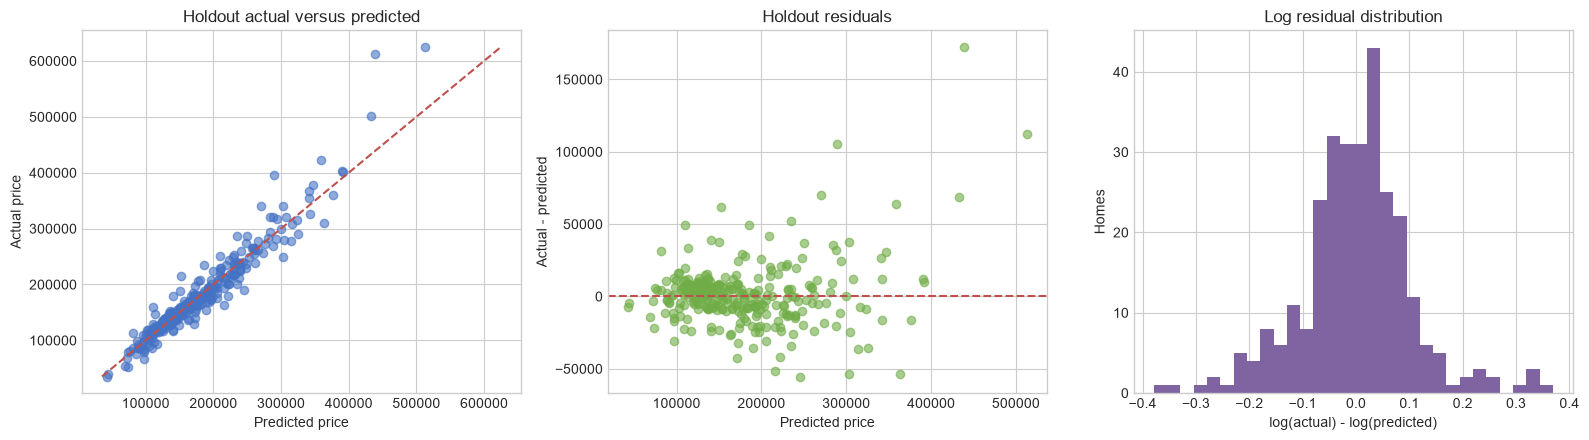

In [28]:
test_residual = y_test - test_prediction
log_residual = np.log1p(y_test) - np.log1p(test_prediction)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].scatter(test_prediction, y_test, alpha=0.6, color="#4472C4")
limits = [min(y_test.min(), test_prediction.min()), max(y_test.max(), test_prediction.max())]
axes[0].plot(limits, limits, color="#C0504D", linestyle="--")
axes[0].set(title="Holdout actual versus predicted", xlabel="Predicted price", ylabel="Actual price")
axes[1].scatter(test_prediction, test_residual, alpha=0.6, color="#70AD47")
axes[1].axhline(0, color="#C0504D", linestyle="--")
axes[1].set(title="Holdout residuals", xlabel="Predicted price", ylabel="Actual - predicted")
axes[2].hist(log_residual, bins=30, color="#8064A2")
axes[2].set(title="Log residual distribution", xlabel="log(actual) - log(predicted)", ylabel="Homes")
plt.tight_layout()
plt.show()

In [29]:
holdout_diagnostics = pd.DataFrame({
    "actual": y_test,
    "predicted": test_prediction,
    "absolute_error": np.abs(test_residual),
    "absolute_percentage_error": np.abs(test_residual) / y_test,
})
holdout_diagnostics["actual_price_quartile"] = pd.qcut(
    holdout_diagnostics["actual"],
    q=4,
    duplicates="drop",
)

error_by_price_band = holdout_diagnostics.groupby(
    "actual_price_quartile",
    observed=True,
).agg(
    homes=("actual", "size"),
    mean_actual_price=("actual", "mean"),
    mae=("absolute_error", "mean"),
    median_absolute_percentage_error=("absolute_percentage_error", "median"),
)
error_by_price_band

,homes,mean_actual_price,mae,median_absolute_percentage_error
actual_price_quartile,,,,
"(35310.999, 129750.0]",73,"105,001.5753","9,101.7426",0.0592
"(129750.0, 163495.0]",73,"144,758.0959","9,071.1153",0.0505
"(163495.0, 214875.0]",73,"185,004.5753","13,892.5331",0.0467
"(214875.0, 625000.0]",73,"288,029.4932","23,971.4073",0.0617


## 12. Model-agnostic feature importance

Permutation importance measures the increase in holdout RMSLE after shuffling one original input column. It works across model families and reports business-level columns rather than hundreds of one-hot features.

Because this uses the holdout set, it is explanatory only. Do not use these values for another round of feature selection without creating a fresh validation design.

In [30]:
permutation = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring=make_scorer(rmsle_clipped, greater_is_better=False),
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

permutation_summary = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": permutation.importances_mean,
        "importance_std": permutation.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
permutation_summary.head(30)

,feature,importance_mean,importance_std
0,GrLivArea,0.0659,0.0068
1,OverallQual,0.0330,0.0037
2,OverallCond,0.0187,0.0021
3,YearBuilt,0.0171,0.0029
4,LotArea,0.0167,0.0014
5,TotalBsmtSF,0.0163,0.0021
6,GarageCars,0.0133,0.0023
7,1stFlrSF,0.0125,0.0021
8,Neighborhood,0.0116,0.0012
9,MSZoning,0.0079,0.0026


## 13. Fit all labelled data and create a Kaggle submission

After model selection and final evaluation are complete, the selected pipeline is refitted on all labelled rows. It then predicts the supplied Kaggle `test.csv`.

The submission is validated against `sample_submission.csv` for row count, columns, identifier order, missing predictions, and nonpositive prices.

In [31]:
production_model = clone(candidate_models[selected_model_name])
production_model.fit(X, y)

kaggle_X = kaggle_test.drop(columns=[ID_COLUMN])
kaggle_prediction = np.clip(production_model.predict(kaggle_X), 0, None)

submission = pd.DataFrame({
    "Id": kaggle_test["Id"],
    "SalePrice": kaggle_prediction,
})

submission_checks = pd.Series({
    "row_count_matches_sample": len(submission) == len(sample_submission),
    "columns_match_sample": submission.columns.tolist() == sample_submission.columns.tolist(),
    "id_order_matches_sample": submission["Id"].equals(sample_submission["Id"]),
    "missing_predictions": submission["SalePrice"].isna().sum(),
    "nonpositive_predictions": (submission["SalePrice"] <= 0).sum(),
})
display(submission_checks.to_frame("result"))

SUBMISSION_PATH = Path("house_price_submission.csv")
submission.to_csv(SUBMISSION_PATH, index=False)
print(f"Saved {SUBMISSION_PATH.resolve()}")
submission.head()

,result
row_count_matches_sample,True
columns_match_sample,True
id_order_matches_sample,True
missing_predictions,0
nonpositive_predictions,0


Saved C:\Users\a2839\PycharmProjects\SqptInterview\HousePriceRegression\house_price_submission.csv


,Id,SalePrice
0,1461,"120,300.5730"
1,1462,"155,162.5259"
2,1463,"180,316.2209"
3,1464,"198,413.6853"
4,1465,"200,638.9270"


## 14. Interview conclusions

A concise presentation should answer these questions:

1. **What is the target and evaluation metric?** Explain why dollar RMSE and RMSLE answer different questions.
2. **What did the data checks reveal?** Distinguish structural absence from genuine missing data and discuss the skewed target.
3. **How strong is the simplest baseline?** Compare median prediction and ordinary linear regression.
4. **What did the log target change?** Discuss proportional errors, residual stability, and the Kaggle metric.
5. **Did feature engineering help?** Show whether a few interpretable area, age, amenity, and quality features improved validation error.
6. **Did regularization help?** Contrast Ridge coefficient shrinkage with Lasso's sparse selection.
7. **Did nonlinear models earn their complexity?** Compare validation gains, runtime, interpretability, and residual behavior.
8. **Where does the model fail?** Discuss error by price segment and influential large homes.
9. **What remains uncertain?** Mention temporal or geographic drift, rare categories, outlier policy, and the difference between Kaggle scoring and a real valuation process.

For a production valuation system, further work would include temporal validation, calibrated prediction intervals, geographic diagnostics, and explicit treatment of renovation and sale-condition timing.